# Customer Churn Prediction Analysis

## Business Problem
Customer churn is a critical business metric that directly impacts revenue and growth.
This analysis aims to:
- Predict which customers are at risk of churning (binary classification)
- Identify actionable drivers of churn
- Provide business recommendations for retention strategies

The goal is not just prediction accuracy, but actionable insights that operations teams can use.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import roc_curve
import warnings

# ── Global plot style ────────────────────────────────────────────────────────
PALETTE  = {'no_churn': '#2D6A4F', 'churn': '#D62828'}
COLORS   = [PALETTE['no_churn'], PALETTE['churn']]
ACCENTS  = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
BG       = '#F8F9FA'
GRID_CLR = '#DEE2E6'

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    GRID_CLR,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        120,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:  ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.tick_params(length=0)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
np.random.seed(42)

print("Environment setup complete")

Environment setup complete


## 2. Load Data

In [2]:
data_path = '/mnt/d/GreenJourney/DataScienceProjects/churn-prediction-gs/data/churn.csv'
df = pd.read_csv(data_path)

print("Dataset loaded successfully")
print(f"\nShape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

Dataset loaded successfully

Shape: (36992, 24)

First few rows:
   Unnamed: 0  age gender security_no region_category  membership_category joining_date joined_through_referral  \
0           0   18      F     XW0DQ7H         Village  Platinum Membership   2017-08-17                      No   
1           1   32      F     5K0N3X1            City   Premium Membership   2017-08-28                       ?   
2           2   44      F     1F2TCL3            Town        No Membership   2016-11-11                     Yes   
3           3   37      M     VJGJ33N            City        No Membership   2016-10-29                     Yes   
4           4   31      F     SVZXCWB            City        No Membership   2017-09-12                      No   

  referral_id     preferred_offer_types medium_of_operation internet_option last_visit_time  days_since_last_login  \
0    xxxxxxxx     Gift Vouchers/Coupons                   ?           Wi-Fi        16:08:02                     17   
1    CID

In [3]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())


Data types:
Unnamed: 0                        int64
age                               int64
gender                              str
security_no                         str
region_category                     str
membership_category                 str
joining_date                        str
joined_through_referral             str
referral_id                         str
preferred_offer_types               str
medium_of_operation                 str
internet_option                     str
last_visit_time                     str
days_since_last_login             int64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days            str
points_in_wallet                float64
used_special_discount               str
offer_application_preference        str
past_complaint                      str
complaint_status                    str
feedback                            str
churn_risk_score                  int64
dtype: object

Missing valu

## 3. Data Understanding and Quality Checks

In [4]:
# Identify column types
id_columns = ['Unnamed: 0', 'security_no', 'referral_id']
date_columns = ['joining_date', 'last_visit_time']
categorical_columns = [
    'gender', 'region_category', 'membership_category', 'joined_through_referral',
    'preferred_offer_types', 'medium_of_operation', 'internet_option',
    'used_special_discount', 'offer_application_preference',
    'past_complaint', 'complaint_status', 'feedback'
]
numerical_columns = [
    'age', 'days_since_last_login', 'avg_time_spent',
    'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet'
]
target = 'churn_risk_score'

print("Column categorization:")
print(f"ID columns: {id_columns}")
print(f"Date columns: {date_columns}")
print(f"Categorical columns: {len(categorical_columns)} columns")
print(f"Numerical columns: {len(numerical_columns)} columns")
print(f"Target: {target}")

Column categorization:
ID columns: ['Unnamed: 0', 'security_no', 'referral_id']
Date columns: ['joining_date', 'last_visit_time']
Categorical columns: 12 columns
Numerical columns: 6 columns
Target: churn_risk_score


In [5]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [6]:
print("\nTarget distribution:")
print(df[target].value_counts())
print(f"\nChurn rate: {df[target].mean():.2%}")


Target distribution:
churn_risk_score
1    20012
0    16980
Name: count, dtype: int64

Churn rate: 54.10%


In [7]:
# Inspect last_visit_time and complaint_status before feature engineering
print("\nlast_visit_time sample values:")
print(df['last_visit_time'].head(10).tolist())

print("\ncomplaint_status value counts:")
print(df['complaint_status'].value_counts())

print("\npast_complaint value counts:")
print(df['past_complaint'].value_counts())


last_visit_time sample values:
['16:08:02', '12:38:13', '22:53:21', '15:57:50', '15:46:44', '06:46:07', '11:40:04', '07:52:43', '06:50:10', '19:10:16']

complaint_status value counts:
complaint_status
Not Applicable              18602
Unsolved                     4644
Solved                       4619
Solved in Follow-up          4577
No Information Available     4550
Name: count, dtype: int64

past_complaint value counts:
past_complaint
No     18602
Yes    18390
Name: count, dtype: int64


## 4. Data Preprocessing

In [8]:
df_clean = df.copy()

# Parse joining_date as a full datetime (used for tenure calculation)
df_clean['joining_date'] = pd.to_datetime(df_clean['joining_date'], errors='coerce')

# NOTE: last_visit_time contains only time-of-day values (HH:MM:SS), not full datetimes.
# Computing days_since_last_visit from this column would be meaningless.
# Instead, we extract last_visit_hour as a proxy for behavioural pattern (e.g. off-hours usage).
df_clean['last_visit_hour'] = pd.to_datetime(
    df_clean['last_visit_time'], format='%H:%M:%S', errors='coerce'
).dt.hour

print("Missing values in last_visit_hour:", df_clean['last_visit_hour'].isnull().sum())

# Some numerical columns are stored as strings in the CSV — coerce to numeric
for col in numerical_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

Missing values in last_visit_hour: 0


## 5. Feature Engineering

In [9]:
# Reference date for tenure (use max joining_date as proxy for current date)
reference_date = df_clean['joining_date'].max()
df_clean['tenure_days'] = (reference_date - df_clean['joining_date']).dt.days

# Engagement score: product of time spent and login frequency
df_clean['engagement_score'] = (
    df_clean['avg_time_spent'] * df_clean['avg_frequency_login_days']
).fillna(0)

# Transaction value per login day
df_clean['value_per_login'] = (
    df_clean['avg_transaction_value'] / (df_clean['avg_frequency_login_days'] + 1)
)

# complaint_open flag:
# Inspection shows complaint_status has exactly two values:
#   - "Solved in Follow-up"      → complaint was resolved
#   - "No Information Available" → no resolution recorded; treated as unresolved
# We flag a customer as having an open complaint only when they have a past complaint
# AND the status is "No Information Available" (i.e. no resolution on record).
# "Not Applicable" does not appear in this dataset, so we do not include it.
df_clean['complaint_open'] = (
    (df_clean['past_complaint'] == 'Yes') &
    (df_clean['complaint_status'] == 'No Information Available')
).astype(int)

print("Feature engineering complete")
print("\nEngineered features:")
print("- tenure_days: customer lifetime in days from joining_date")
print("- engagement_score: avg_time_spent x avg_frequency_login_days")
print("- value_per_login: avg_transaction_value per login day")
print("- last_visit_hour: hour of day of last visit (time-of-day behavioural signal)")
print("- complaint_open: past complaint with no resolution on record")

print("\ncomplaint_open distribution:")
print(df_clean['complaint_open'].value_counts())

Feature engineering complete

Engineered features:
- tenure_days: customer lifetime in days from joining_date
- engagement_score: avg_time_spent x avg_frequency_login_days
- value_per_login: avg_transaction_value per login day
- last_visit_hour: hour of day of last visit (time-of-day behavioural signal)
- complaint_open: past complaint with no resolution on record

complaint_open distribution:
complaint_open
0    32442
1     4550
Name: count, dtype: int64


## 6. Exploratory Data Analysis

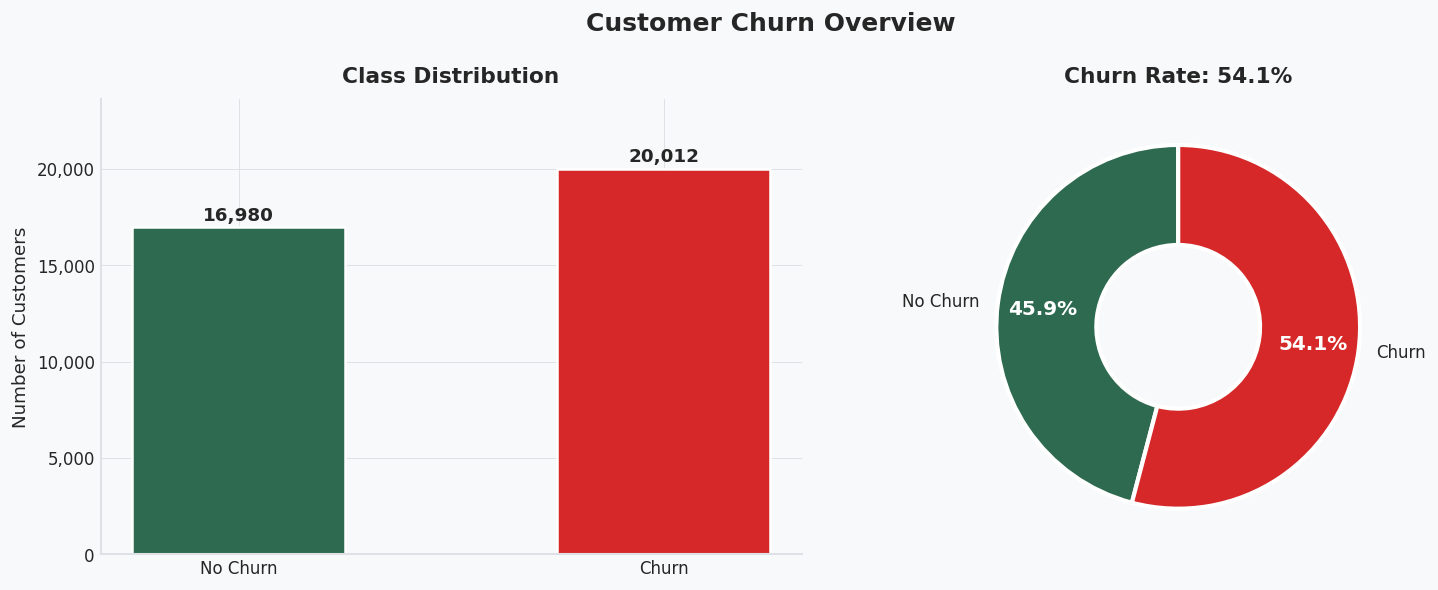

No Churn: 16,980  |  Churn: 20,012  |  Ratio: 0.85:1


In [10]:
# ── Chart 1: Target distribution ────────────────────────────────────────────────
counts     = df_clean[target].value_counts().sort_index()
labels     = ['No Churn', 'Churn']
churn_rate = df_clean[target].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold')

bars = axes[0].bar(labels, counts.values, color=COLORS, width=0.5,
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, counts.max() * 1.18)
style_ax(axes[0], 'Class Distribution', '', 'Number of Customers')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=COLORS,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2.5}
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
axes[1].set_title(f'Churn Rate: {churn_rate:.1%}', pad=10, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"No Churn: {counts[0]:,}  |  Churn: {counts[1]:,}  |  Ratio: {counts[0]/counts[1]:.2f}:1")

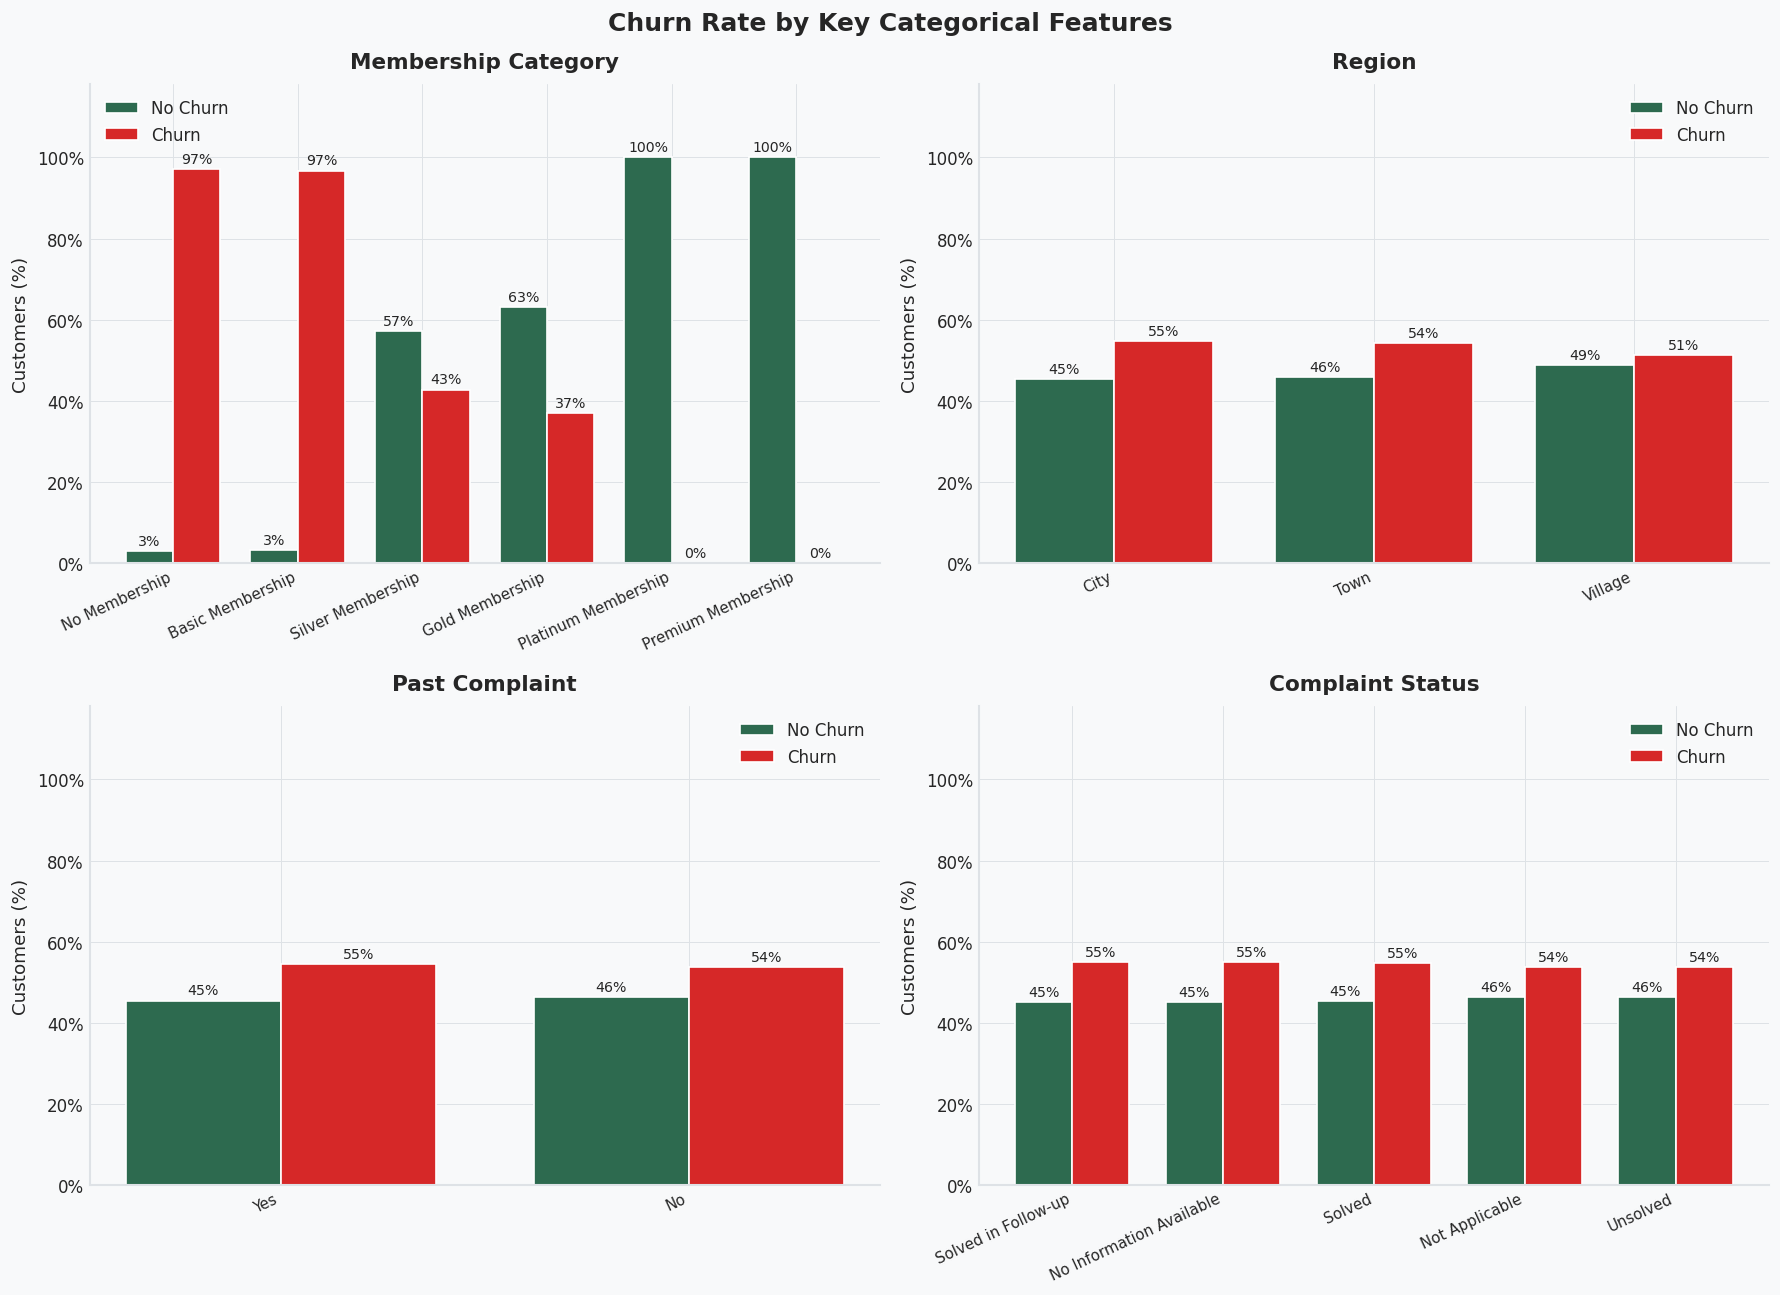

In [11]:
# ── Chart 2: Churn rate by key categorical features ───────────────────────────
cat_features = [
    ('membership_category', 'Membership Category'),
    ('region_category',     'Region'),
    ('past_complaint',      'Past Complaint'),
    ('complaint_status',    'Complaint Status'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Churn Rate by Key Categorical Features', fontsize=15, fontweight='bold')

for ax, (col, title) in zip(axes.flat, cat_features):
    ct = pd.crosstab(df_clean[col], df_clean[target], normalize='index') * 100
    ct.columns = ['No Churn', 'Churn']
    ct = ct.sort_values('Churn', ascending=False)
    x = np.arange(len(ct))
    w = 0.38
    b1 = ax.bar(x - w/2, ct['No Churn'], width=w, color=PALETTE['no_churn'],
                label='No Churn', edgecolor='white')
    b2 = ax.bar(x + w/2, ct['Churn'],    width=w, color=PALETTE['churn'],
                label='Churn',    edgecolor='white')
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels(ct.index, rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylim(0, 118)
    ax.legend(frameon=False)
    style_ax(ax, title, '', 'Customers (%)')

plt.tight_layout()
plt.show()

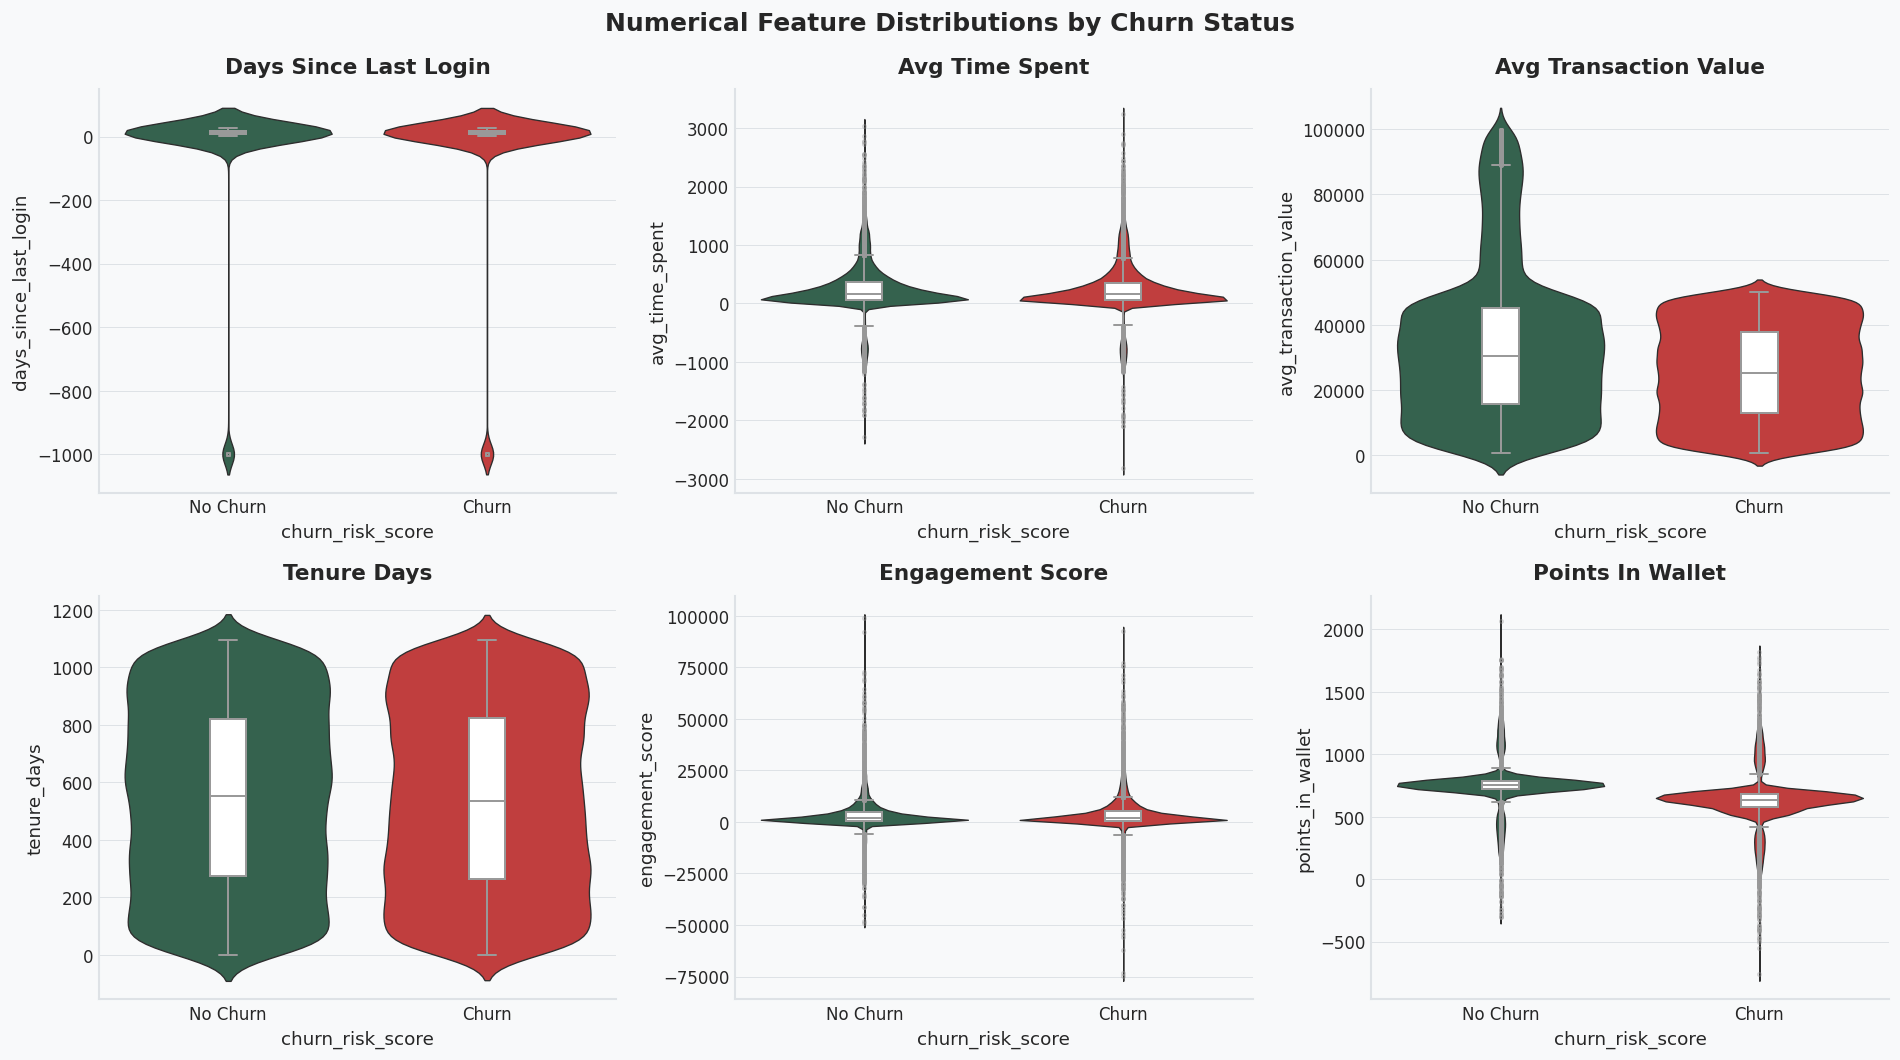

In [12]:
# ── Chart 3: Numerical features — violin + box overlay ─────────────────────────
engineered_numerical = [
    'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
    'tenure_days', 'engagement_score', 'points_in_wallet'
]
plot_df = df_clean[engineered_numerical + [target]].copy()
plot_df[target] = plot_df[target].map({0: 'No Churn', 1: 'Churn'})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Numerical Feature Distributions by Churn Status', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flat, engineered_numerical):
    sns.violinplot(data=plot_df, x=target, y=col, palette=COLORS,
                   order=['No Churn', 'Churn'], inner=None, linewidth=0.8, ax=ax)
    sns.boxplot(data=plot_df, x=target, y=col, order=['No Churn', 'Churn'],
                width=0.14, color='white', linewidth=1.2,
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.4}, ax=ax)
    style_ax(ax, col.replace('_', ' ').title(), '', '')

plt.tight_layout()
plt.show()

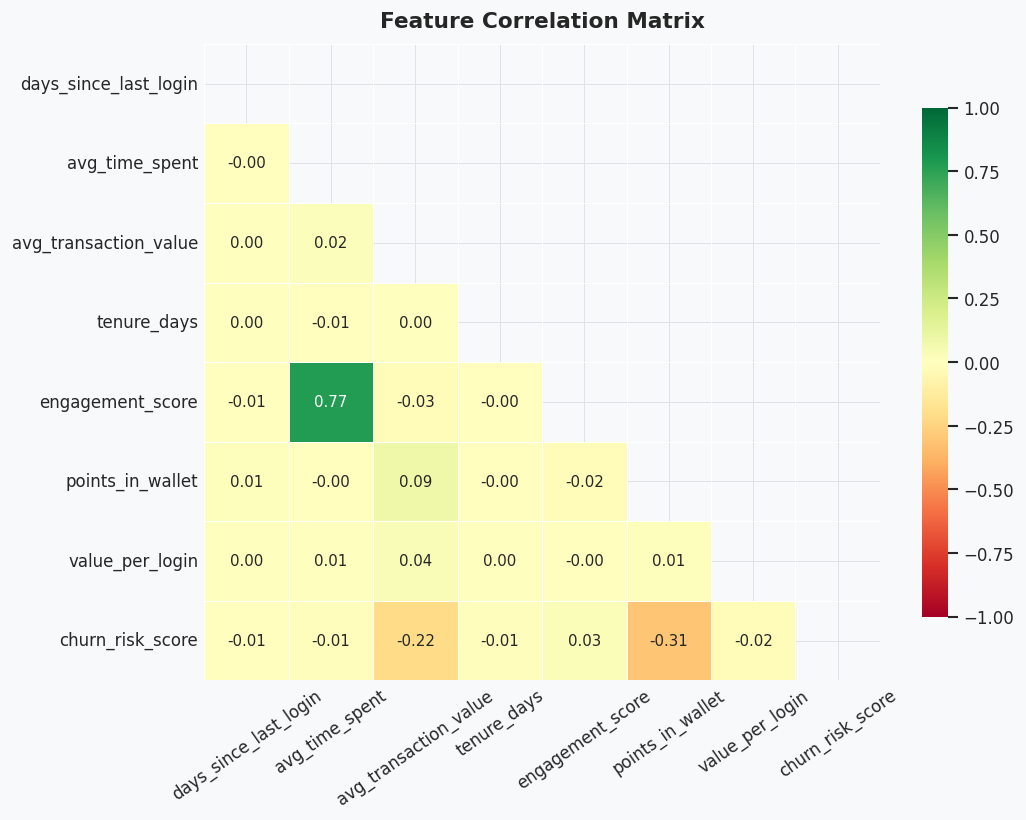


Correlation with churn:
engagement_score         0.026967
days_since_last_login   -0.006228
tenure_days             -0.009913
avg_time_spent          -0.014263
value_per_login         -0.021365
avg_transaction_value   -0.218012
points_in_wallet        -0.307439
Name: churn_risk_score, dtype: float64


In [13]:
# ── Chart 4: Correlation heatmap ──────────────────────────────────────────────────
corr_cols   = engineered_numerical + ['value_per_login', target]
corr_matrix = df_clean[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax, cbar_kws={'shrink': 0.8}
)
style_ax(ax, 'Feature Correlation Matrix')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

correlations = corr_matrix[target].drop(target).sort_values(ascending=False)
print("\nCorrelation with churn:")
print(correlations)

## 7. Prepare Data for Modeling

In [14]:
# Columns dropped: identifiers (no predictive value, leakage risk) and raw date/time columns
# (joining_date and last_visit_time are replaced by tenure_days and last_visit_hour)
drop_columns = id_columns + date_columns

df_model = df_clean.drop(columns=drop_columns)

# Define feature sets for the ColumnTransformer
# last_visit_hour is treated as numerical (ordinal hour 0-23)
numerical_features_model = numerical_columns + [
    'tenure_days', 'engagement_score', 'value_per_login', 'last_visit_hour'
]
# complaint_open is already binary (0/1), no encoding needed
passthrough_features = ['complaint_open']

X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features: 23
Samples: 36992

Target distribution:
churn_risk_score
1    20012
0    16980
Name: count, dtype: int64


## 8. Train-Test Split

The test set is held out entirely and used only for final evaluation of the selected model.
All model comparison and selection is done via cross-validation on the training set.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training set: 29593 samples
Test set: 7399 samples

Train churn rate: 54.10%
Test churn rate: 54.10%


## 9. Preprocessing Pipelines

Transformations are fit on training data only to prevent leakage.
- Logistic Regression uses a full Pipeline with OneHotEncoder + StandardScaler
- Tree-based models use a simpler ColumnTransformer (no scaling needed)

In [16]:
# Identify nominal categorical columns present in X
nominal_cats = [c for c in categorical_columns if c in X.columns]

# Imputer + scaler pipeline for numerical features (Logistic Regression)
num_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Imputer-only pipeline for numerical features (tree-based models)
num_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Imputer + encoder pipeline for categorical features
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor for Logistic Regression: impute + scale numericals, impute + OHE categoricals
lr_preprocessor = ColumnTransformer(transformers=[
    ('num', num_lr, numerical_features_model),
    ('cat', cat_pipe, nominal_cats),
    ('pass', 'passthrough', passthrough_features)
])

# Preprocessor for tree-based models: impute numericals, impute + OHE categoricals, no scaling
tree_preprocessor = ColumnTransformer(transformers=[
    ('num', num_tree, numerical_features_model),
    ('cat', cat_pipe, nominal_cats),
    ('pass', 'passthrough', passthrough_features)
])

# Full pipelines
lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

rf_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=20,
        random_state=42, class_weight='balanced', n_jobs=-1
    ))
])

gb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ))
])

print("Pipelines defined")

Pipelines defined


## 10. Cross-Validation on Training Set

Model selection is based on stratified cross-validation on the training set only.
The test set is not touched at this stage.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline,
}

cv_results = {}
print("Running 5-fold stratified cross-validation on training set (scoring: F1)...\n")

for name, pipeline in candidates.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: mean F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})")

Running 5-fold stratified cross-validation on training set (scoring: F1)...

Logistic Regression: mean F1 = 0.8675  (+/- 0.0027)
Random Forest: mean F1 = 0.9326  (+/- 0.0021)
Gradient Boosting: mean F1 = 0.9401  (+/- 0.0029)



Cross-validation summary:
                     cv_f1_mean  cv_f1_std
Logistic Regression    0.867549   0.002731
Random Forest          0.932629   0.002079
Gradient Boosting      0.940091   0.002875


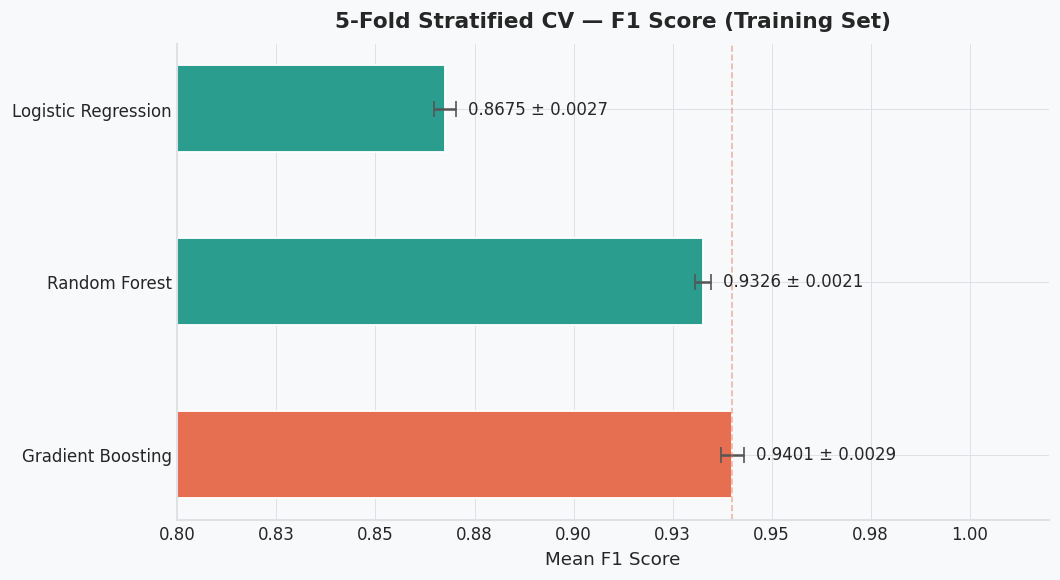

In [18]:
cv_summary = pd.DataFrame({
    name: {'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()}
    for name, scores in cv_results.items()
}).T

print("\nCross-validation summary:")
print(cv_summary)

# ── Chart 5: CV comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
means = cv_summary['cv_f1_mean']
stds  = cv_summary['cv_f1_std']
best  = means.idxmax()
bar_colors = [ACCENTS[4] if n == best else ACCENTS[1] for n in means.index]
bars = ax.barh(means.index, means, xerr=stds, color=bar_colors, capsize=5,
               edgecolor='white', linewidth=1.1, height=0.5,
               error_kw={'elinewidth': 1.5, 'ecolor': '#555'})
for bar, val, std in zip(bars, means, stds):
    ax.text(val + std + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f} ± {std:.4f}', va='center', fontsize=10)
ax.set_xlim(0.80, 1.02)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.axvline(means.max(), color=ACCENTS[4], linestyle='--', linewidth=1, alpha=0.5)
ax.invert_yaxis()
style_ax(ax, '5-Fold Stratified CV — F1 Score (Training Set)', 'Mean F1 Score', '')
plt.tight_layout()
plt.show()

## 11. Model Selection

The model with the highest mean CV F1 on the training set is selected.
The test set is used only once, for final evaluation of the chosen model.

In [19]:
best_model_name = cv_summary['cv_f1_mean'].idxmax()
best_pipeline = candidates[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"CV F1 mean: {cv_summary.loc[best_model_name, 'cv_f1_mean']:.4f}")
print(f"Rationale: highest mean F1 across 5 stratified folds on training data")
print(f"\nFitting selected model on full training set...")

best_pipeline.fit(X_train, y_train)
print("Done.")

Selected model: Gradient Boosting
CV F1 mean: 0.9401
Rationale: highest mean F1 across 5 stratified folds on training data

Fitting selected model on full training set...
Done.


## 12. Final Evaluation on Held-Out Test Set

This section is run once, after model selection is complete.

In [20]:
def evaluate_model(pipeline, X_tr, X_te, y_tr, y_te, model_name):
    """Evaluate a fitted pipeline on train and test sets."""
    y_train_pred = pipeline.predict(X_tr)
    y_test_pred = pipeline.predict(X_te)
    y_test_proba = pipeline.predict_proba(X_te)[:, 1]

    print(f"\n{'='*60}")
    print(f"{model_name} — Final Evaluation")
    print(f"{'='*60}")

    print("\nTrain Metrics:")
    print(f"  F1:        {f1_score(y_tr, y_train_pred):.4f}")
    print(f"  Precision: {precision_score(y_tr, y_train_pred):.4f}")
    print(f"  Recall:    {recall_score(y_tr, y_train_pred):.4f}")

    print("\nTest Metrics:")
    print(f"  F1:        {f1_score(y_te, y_test_pred):.4f}")
    print(f"  Precision: {precision_score(y_te, y_test_pred):.4f}")
    print(f"  Recall:    {recall_score(y_te, y_test_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_te, y_test_proba):.4f}")

    print("\nClassification Report (Test):")
    print(classification_report(y_te, y_test_pred, target_names=['No Churn', 'Churn']))

    # ── Chart 6: Confusion matrix + ROC curve ─────────────────────────────────────
    cm = confusion_matrix(y_te, y_test_pred)
    fpr, tpr, _ = roc_curve(y_te, y_test_proba)
    auc_val = roc_auc_score(y_te, y_test_proba)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{model_name} — Final Evaluation (Test Set)',
                 fontsize=14, fontweight='bold')

    # Confusion matrix with counts + row percentages
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f'{v:,}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                        for rv, rp in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', linewidths=1,
                linecolor='white', annot_kws={'size': 11},
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=axes[0], cbar_kws={'shrink': 0.8})
    style_ax(axes[0], 'Confusion Matrix', 'Predicted', 'Actual')

    # ROC curve with AUC fill
    axes[1].plot(fpr, tpr, color=ACCENTS[4], lw=2.5, label=f'AUC = {auc_val:.4f}')
    axes[1].fill_between(fpr, tpr, alpha=0.08, color=ACCENTS[4])
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')
    axes[1].set_xlim([-0.01, 1.01])
    axes[1].set_ylim([-0.01, 1.05])
    axes[1].legend(loc='lower right', frameon=True)
    style_ax(axes[1], 'ROC Curve', 'False Positive Rate', 'True Positive Rate')

    plt.tight_layout()
    plt.show()

    return {
        'f1': f1_score(y_te, y_test_pred),
        'precision': precision_score(y_te, y_test_pred),
        'recall': recall_score(y_te, y_test_pred),
        'roc_auc': roc_auc_score(y_te, y_test_proba)
    }


Gradient Boosting — Final Evaluation

Train Metrics:
  F1:        0.9501
  Precision: 0.9488
  Recall:    0.9515

Test Metrics:
  F1:        0.9396
  Precision: 0.9356
  Recall:    0.9435
  ROC-AUC:   0.9756

Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.93      0.92      0.93      3396
       Churn       0.94      0.94      0.94      4003

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399



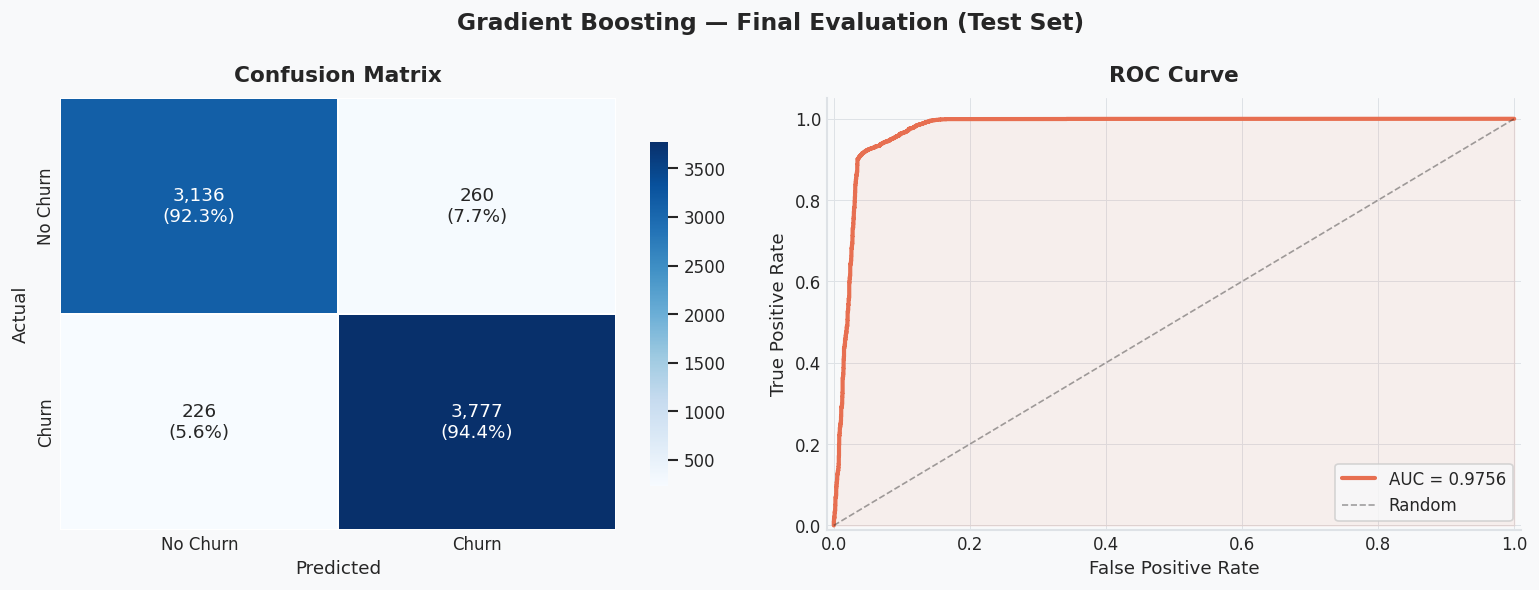

In [21]:
final_metrics = evaluate_model(best_pipeline, X_train, X_test, y_train, y_test, best_model_name)

## 13. Model Explainability

In [22]:
# Feature names after preprocessing
try:
    ohe_feature_names = (
        best_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(nominal_cats)
        .tolist()
    )
    all_feature_names = numerical_features_model + ohe_feature_names + passthrough_features
except Exception:
    all_feature_names = list(X.columns)


Top 15 Feature Importances (Gradient Boosting):
                                feature  importance
                       points_in_wallet    0.573521
      membership_category_No Membership    0.130123
   membership_category_Basic Membership    0.114017
membership_category_Platinum Membership    0.063945
 membership_category_Premium Membership    0.063212
                  avg_transaction_value    0.016943
    membership_category_Gold Membership    0.011570
  membership_category_Silver Membership    0.007068
              feedback_Reasonable Price    0.002861
         feedback_Quality Customer Care    0.002535
      feedback_Products always in Stock    0.002332
         feedback_User Friendly Website    0.002262
                        value_per_login    0.001526
                         avg_time_spent    0.001337
                            tenure_days    0.001136


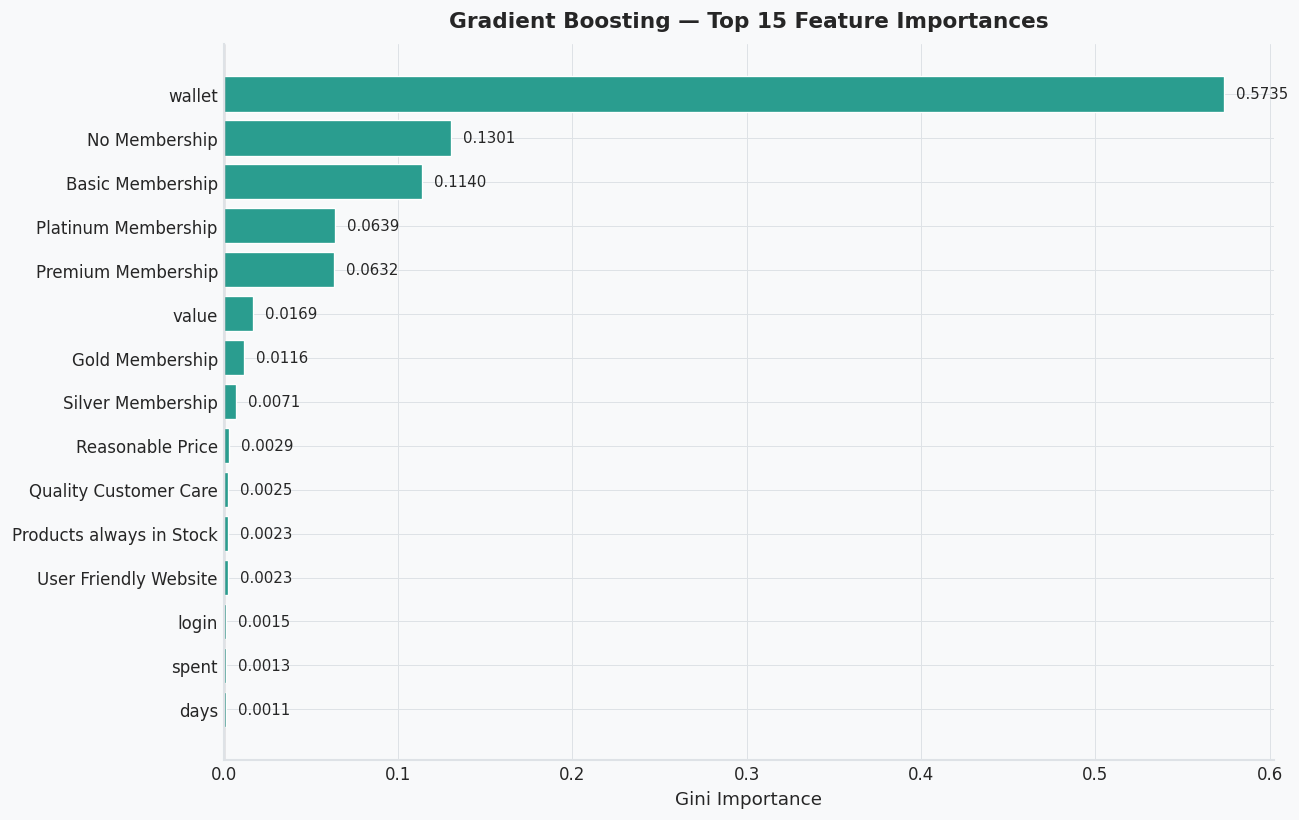

In [23]:
inner_model = best_pipeline.named_steps['model']

def _importance_chart(df_imp, value_col, title, xlabel, color):
    """Reusable professional horizontal importance bar chart."""
    top = df_imp.head(15).copy()
    top['label'] = top['feature'].str.replace(r'^[a-z_]+_', '', regex=True)
    bar_colors = [color if v >= 0 else PALETTE['churn'] for v in top[value_col]]
    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(top['label'], top[value_col], color=bar_colors,
                   edgecolor='white', linewidth=0.8)
    max_val = top[value_col].abs().max()
    for bar, val in zip(bars, top[value_col]):
        ax.text(val + max_val * 0.012, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='#888', linewidth=0.8)
    style_ax(ax, title, xlabel, '')
    plt.tight_layout()
    plt.show()

if hasattr(inner_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': all_feature_names,
        'importance': inner_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTop 15 Feature Importances ({best_model_name}):")
    print(feature_importance.head(15).to_string(index=False))
    _importance_chart(feature_importance, 'importance',
                      f'{best_model_name} — Top 15 Feature Importances',
                      'Gini Importance', ACCENTS[1])

elif hasattr(inner_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': all_feature_names,
        'coefficient': inner_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)

    print(f"\nTop 15 Feature Coefficients ({best_model_name}):")
    print(feature_importance.head(15).to_string(index=False))
    _importance_chart(feature_importance, 'coefficient',
                      f'{best_model_name} — Top 15 Feature Coefficients',
                      'Coefficient', ACCENTS[1])


Calculating permutation importance on test set...

Top 15 Permutation Importances:
                                feature  importance
   membership_category_Basic Membership    0.097729
      membership_category_No Membership    0.096432
                       points_in_wallet    0.088688
membership_category_Platinum Membership    0.056278
 membership_category_Premium Membership    0.055872
                  avg_transaction_value    0.024720
      feedback_Products always in Stock    0.014353
         feedback_Quality Customer Care    0.013137
         feedback_User Friendly Website    0.013002
              feedback_Reasonable Price    0.003027
  membership_category_Silver Membership    0.001162
    membership_category_Gold Membership    0.000770
               avg_frequency_login_days    0.000365
                         complaint_open    0.000203
          feedback_Poor Product Quality    0.000203


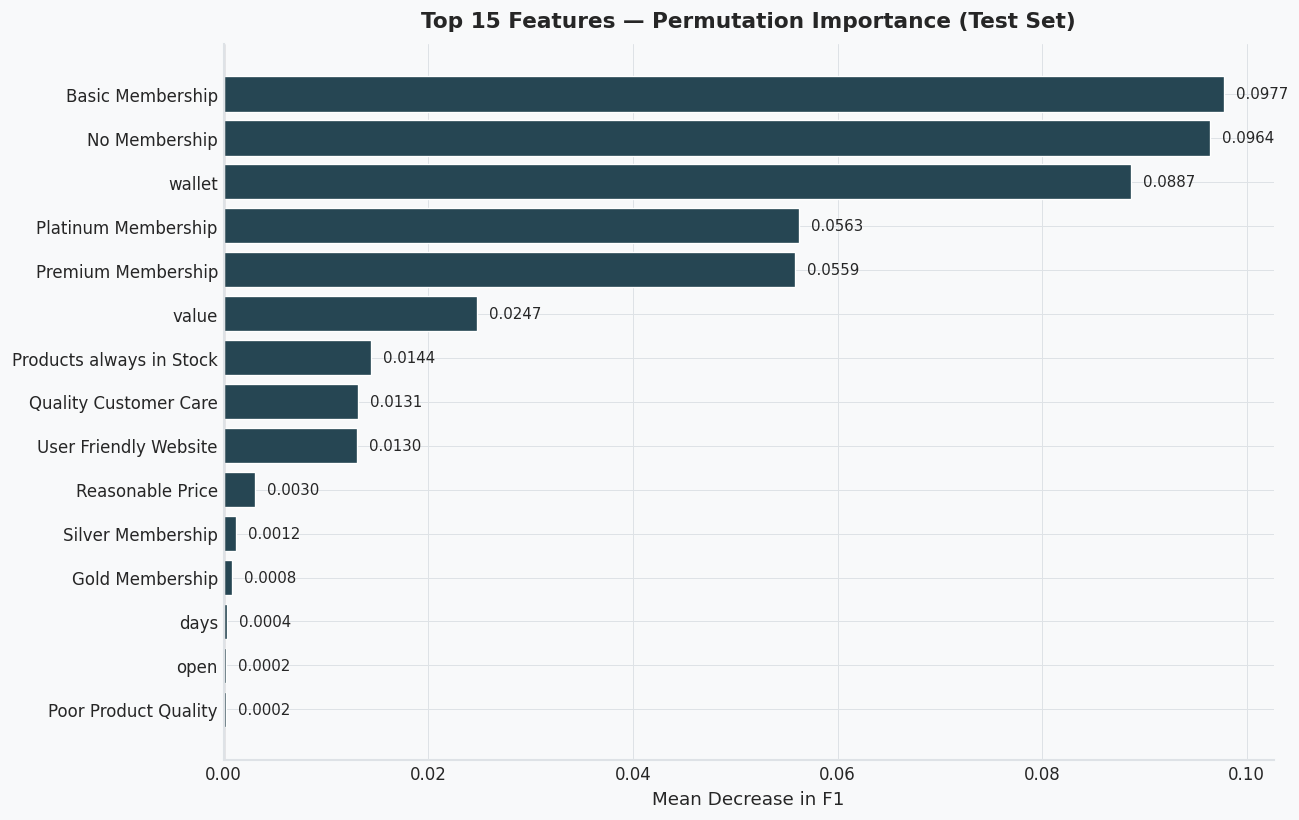

In [24]:
# Permutation importance on the test set (model-agnostic, uses the full pipeline)
print("\nCalculating permutation importance on test set...")
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

perm_imp = permutation_importance(
    inner_model, X_test_transformed, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': perm_imp.importances_mean
}).sort_values('importance', ascending=False)

print("\nTop 15 Permutation Importances:")
print(perm_importance_df.head(15).to_string(index=False))
_importance_chart(perm_importance_df, 'importance',
                  'Top 15 Features — Permutation Importance (Test Set)',
                  'Mean Decrease in F1', ACCENTS[0])

## 14. Business Insights and Recommendations

In [25]:
print("\n" + "="*80)
print("BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("="*80)

print("\n1. KEY CHURN DRIVERS:")
print("-" * 80)
top_features = perm_importance_df.head(10)['feature'].tolist()
print("Based on permutation importance, the strongest churn predictors are:")
for i, feature in enumerate(top_features[:5], 1):
    print(f"   {i}. {feature}")

print("\n2. HIGH-RISK CUSTOMER SEGMENTS:")
print("-" * 80)
print("   • Customers with unresolved complaints (complaint_open = 1)")
print("   • Customers with high days_since_last_login (inactive users)")
print("   • Customers with low engagement_score (low activity)")
print("   • Customers with low avg_time_spent on platform")
print("   • Certain membership categories show higher churn rates")

print("\n3. ACTIONABLE RECOMMENDATIONS:")
print("-" * 80)
print("   A. Complaint Resolution Priority")
print("      → Immediately address all open/unresolved complaints")
print("      → Implement proactive outreach for customers with past complaints")
print("      → Track complaint resolution time as a KPI")

print("\n   B. Re-engagement Campaigns")
print("      → Target customers with >30 days since last login")
print("      → Personalised offers based on preferred_offer_types")
print("      → Win-back campaigns for low engagement customers")

print("\n   C. Membership Optimisation")
print("      → Review pricing and benefits for high-churn membership tiers")
print("      → Offer upgrade incentives to retain valuable customers")
print("      → Create loyalty programs for long-tenure customers")

print("\n   D. Proactive Retention")
print("      → Score all customers monthly using this model")
print("      → Trigger interventions for customers with churn probability > 0.6")
print("      → A/B test retention offers on medium-risk customers (0.4–0.6)")

print("\n4. EXPECTED BUSINESS IMPACT:")
print("-" * 80)
print(f"   • Model recall:    {final_metrics['recall']:.1%} of churners identified")
print(f"   • Model precision: {final_metrics['precision']:.1%} of flagged customers are true churners")
print("   • If 20% of identified churners are saved through intervention:")
print(f"     → Potential churn reduction: ~{final_metrics['recall'] * 0.20:.1%} of total churn")


BUSINESS INSIGHTS AND RECOMMENDATIONS

1. KEY CHURN DRIVERS:
--------------------------------------------------------------------------------
Based on permutation importance, the strongest churn predictors are:
   1. membership_category_Basic Membership
   2. membership_category_No Membership
   3. points_in_wallet
   4. membership_category_Platinum Membership
   5. membership_category_Premium Membership

2. HIGH-RISK CUSTOMER SEGMENTS:
--------------------------------------------------------------------------------
   • Customers with unresolved complaints (complaint_open = 1)
   • Customers with high days_since_last_login (inactive users)
   • Customers with low engagement_score (low activity)
   • Customers with low avg_time_spent on platform
   • Certain membership categories show higher churn rates

3. ACTIONABLE RECOMMENDATIONS:
--------------------------------------------------------------------------------
   A. Complaint Resolution Priority
      → Immediately address all ope

## 15. Next Steps and Production Considerations

In [26]:
print("\n" + "="*80)
print("NEXT STEPS FOR PRODUCTION DEPLOYMENT")
print("="*80)

print("\n1. MODEL VALIDATION:")
print("-" * 80)
print("   • Conduct A/B test: control group (no intervention) vs treatment group")
print("   • Validate model performance on out-of-time data (next 3 months)")
print("   • Calculate ROI: cost of interventions vs value of retained customers")

print("\n2. PRODUCTION PIPELINE:")
print("-" * 80)
print("   • Automate data pipeline to refresh customer features daily/weekly")
print("   • Deploy model as REST API or batch scoring service")
print("   • Integrate churn scores into CRM system for operations team")
print("   • Create dashboard for monitoring high-risk customers")

print("\n3. DATA QUALITY AND MONITORING:")
print("-" * 80)
print("   • Monitor feature distributions for data drift")
print("   • Set up alerts for missing data or anomalous values")
print("   • Track model performance metrics over time")
print("   • Implement feedback loop: track actual churn vs predictions")

print("\n4. MODEL MAINTENANCE:")
print("-" * 80)
print("   • Retrain model quarterly with new data")
print("   • Monitor for concept drift (changing churn patterns)")
print("   • Version control for models and features")

print("\n5. OPERATIONAL INTEGRATION:")
print("-" * 80)
print("   • Train customer success team on using churn scores")
print("   • Define intervention playbooks for different risk levels:")
print("     → High risk (> 0.7):   immediate personal outreach")
print("     → Medium risk (0.4–0.7): targeted offers and campaigns")
print("     → Low risk (< 0.4):    standard engagement")

print("\n6. ETHICAL AND PRIVACY CONSIDERATIONS:")
print("-" * 80)
print("   • Ensure compliance with data privacy regulations")
print("   • Avoid discriminatory patterns in model predictions")
print("   • Regular bias audits across customer segments")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nSelected model:  {best_model_name}")
print(f"CV F1 (mean):    {cv_summary.loc[best_model_name, 'cv_f1_mean']:.4f}")
print(f"Test F1:         {final_metrics['f1']:.4f}")
print(f"Test Recall:     {final_metrics['recall']:.4f}")
print(f"Test ROC-AUC:    {final_metrics['roc_auc']:.4f}")
print("\nThis model is ready for business review and pilot testing.")


NEXT STEPS FOR PRODUCTION DEPLOYMENT

1. MODEL VALIDATION:
--------------------------------------------------------------------------------
   • Conduct A/B test: control group (no intervention) vs treatment group
   • Validate model performance on out-of-time data (next 3 months)
   • Calculate ROI: cost of interventions vs value of retained customers

2. PRODUCTION PIPELINE:
--------------------------------------------------------------------------------
   • Automate data pipeline to refresh customer features daily/weekly
   • Deploy model as REST API or batch scoring service
   • Integrate churn scores into CRM system for operations team
   • Create dashboard for monitoring high-risk customers

3. DATA QUALITY AND MONITORING:
--------------------------------------------------------------------------------
   • Monitor feature distributions for data drift
   • Set up alerts for missing data or anomalous values
   • Track model performance metrics over time
   • Implement feedback l